# Module 2 — Evaluation & Analysis

Five mandatory evaluation protocols: topology map, circuit overlap, layer evolution, compositionality, and marginalization robustness.

In [ ]:
# Cell 1 – Setup
import subprocess, sys, os, shutil
for pkg in ["h5py", "umap-learn", "seaborn", "matplotlib", "numpy", "pandas", "tqdm"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    mp = "/content/drive"
    subprocess.run(["fusermount", "-uz", mp], capture_output=True)
    if os.path.isdir(mp):
        shutil.rmtree(mp, ignore_errors=True)
    drive.mount(mp)

if IN_COLAB:
    DATA_DIR = "/content/drive/MyDrive/DATA/CSP-Atlas"
else:
    DATA_DIR = "/Users/piotrwilam/DATA/CSP-Atlas"

LOCAL_SRC = "/Users/piotrwilam/Code/CSP-Atlas/src"
COLAB_SRC = "/content/drive/MyDrive/CODE/CSP-Atlas/src"
SRC_PATH  = LOCAL_SRC if os.path.isdir(LOCAL_SRC) else COLAB_SRC
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

# Configuration
UNIVERSAL_FILE = "universal_106x50.h5"
ATLAS_HDF5 = f"{DATA_DIR}/{UNIVERSAL_FILE}"

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, h5py, json
from module2.io_utils import load_atlas_hdf5
from module2.metrics  import jaccard_similarity, entanglement_index

atlas = load_atlas_hdf5(ATLAS_HDF5)
pair_masks       = atlas["pair_masks"]
universal_masks  = atlas["universal_masks"]
metrics          = atlas["metrics"]
metadata         = atlas["metadata"]

print("Atlas loaded")
print(f"  File           : {UNIVERSAL_FILE}")
print(f"  Pairs          : {len(pair_masks)}")
print(f"  Universal AST  : {len(universal_masks['ast'])}")
print(f"  Universal Blt  : {len(universal_masks['builtin'])}")
print(f"  Metadata       : {metadata}")

## Protocol 1: Topology Map (UMAP)

In [ ]:
# Cell 2 – Protocol 1: Topology Map (UMAP) — Universal AST modules
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("umap-learn not installed — skipping UMAP plots (install with: pip install umap-learn)")

import numpy as np, matplotlib.pyplot as plt

REP_LAYER  = 4
ast_names  = [n for n in sorted(universal_masks["ast"]) if REP_LAYER in universal_masks["ast"][n]]
ast_vecs   = np.array([universal_masks["ast"][n][REP_LAYER].astype(np.float32) for n in ast_names])

if not HAS_UMAP:
    print(f"  ({len(ast_names)} AST modules ready — install umap-learn to plot)")
elif len(ast_names) < 3:
    print(f"Only {len(ast_names)} AST modules at layer {REP_LAYER} — skipping UMAP (need >= 3)")
else:
    reducer = umap.UMAP(metric="jaccard", n_neighbors=min(10, len(ast_names)-1),
                        min_dist=0.1, random_state=42, verbose=False)
    emb = reducer.fit_transform(ast_vecs)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(emb[:, 0], emb[:, 1], s=30, alpha=0.7)
    for i, name in enumerate(ast_names):
        ax.annotate(name, (emb[i, 0], emb[i, 1]), fontsize=6, ha="center", va="bottom")
    ax.set_title("UMAP — Universal AST Modules (Jaccard metric, layer 4)")
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    plt.tight_layout(); plt.show()
    print(f"Plotted {len(emb)} AST modules")

umap-learn not installed — skipping UMAP plots (install with: pip install umap-learn)
  (43 AST modules ready — install umap-learn to plot)


In [ ]:
# Cell 3 – Protocol 1 continued: UMAP for Universal Builtin modules
import numpy as np, matplotlib.pyplot as plt

blt_names = [n for n in sorted(universal_masks["builtin"]) if REP_LAYER in universal_masks["builtin"][n]]
blt_vecs  = np.array([universal_masks["builtin"][n][REP_LAYER].astype(np.float32) for n in blt_names])

if not HAS_UMAP:
    print(f"  ({len(blt_names)} Builtin modules ready — install umap-learn to plot)")
elif len(blt_names) < 3:
    print(f"Only {len(blt_names)} Builtin modules at layer {REP_LAYER} — skipping UMAP (need >= 3)")
else:
    reducer_b = umap.UMAP(metric="jaccard", n_neighbors=min(10, len(blt_names)-1),
                           min_dist=0.1, random_state=42, verbose=False)
    emb_b = reducer_b.fit_transform(blt_vecs)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(emb_b[:, 0], emb_b[:, 1], s=30, alpha=0.7, color="orange")
    for i, name in enumerate(blt_names):
        ax.annotate(name, (emb_b[i, 0], emb_b[i, 1]), fontsize=6, ha="center", va="bottom")
    ax.set_title("UMAP — Universal Builtin Modules (Jaccard metric, layer 4)")
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    plt.tight_layout(); plt.show()

  (63 Builtin modules ready — install umap-learn to plot)


## Protocol 2: Circuit Overlap (Jaccard Heatmaps)

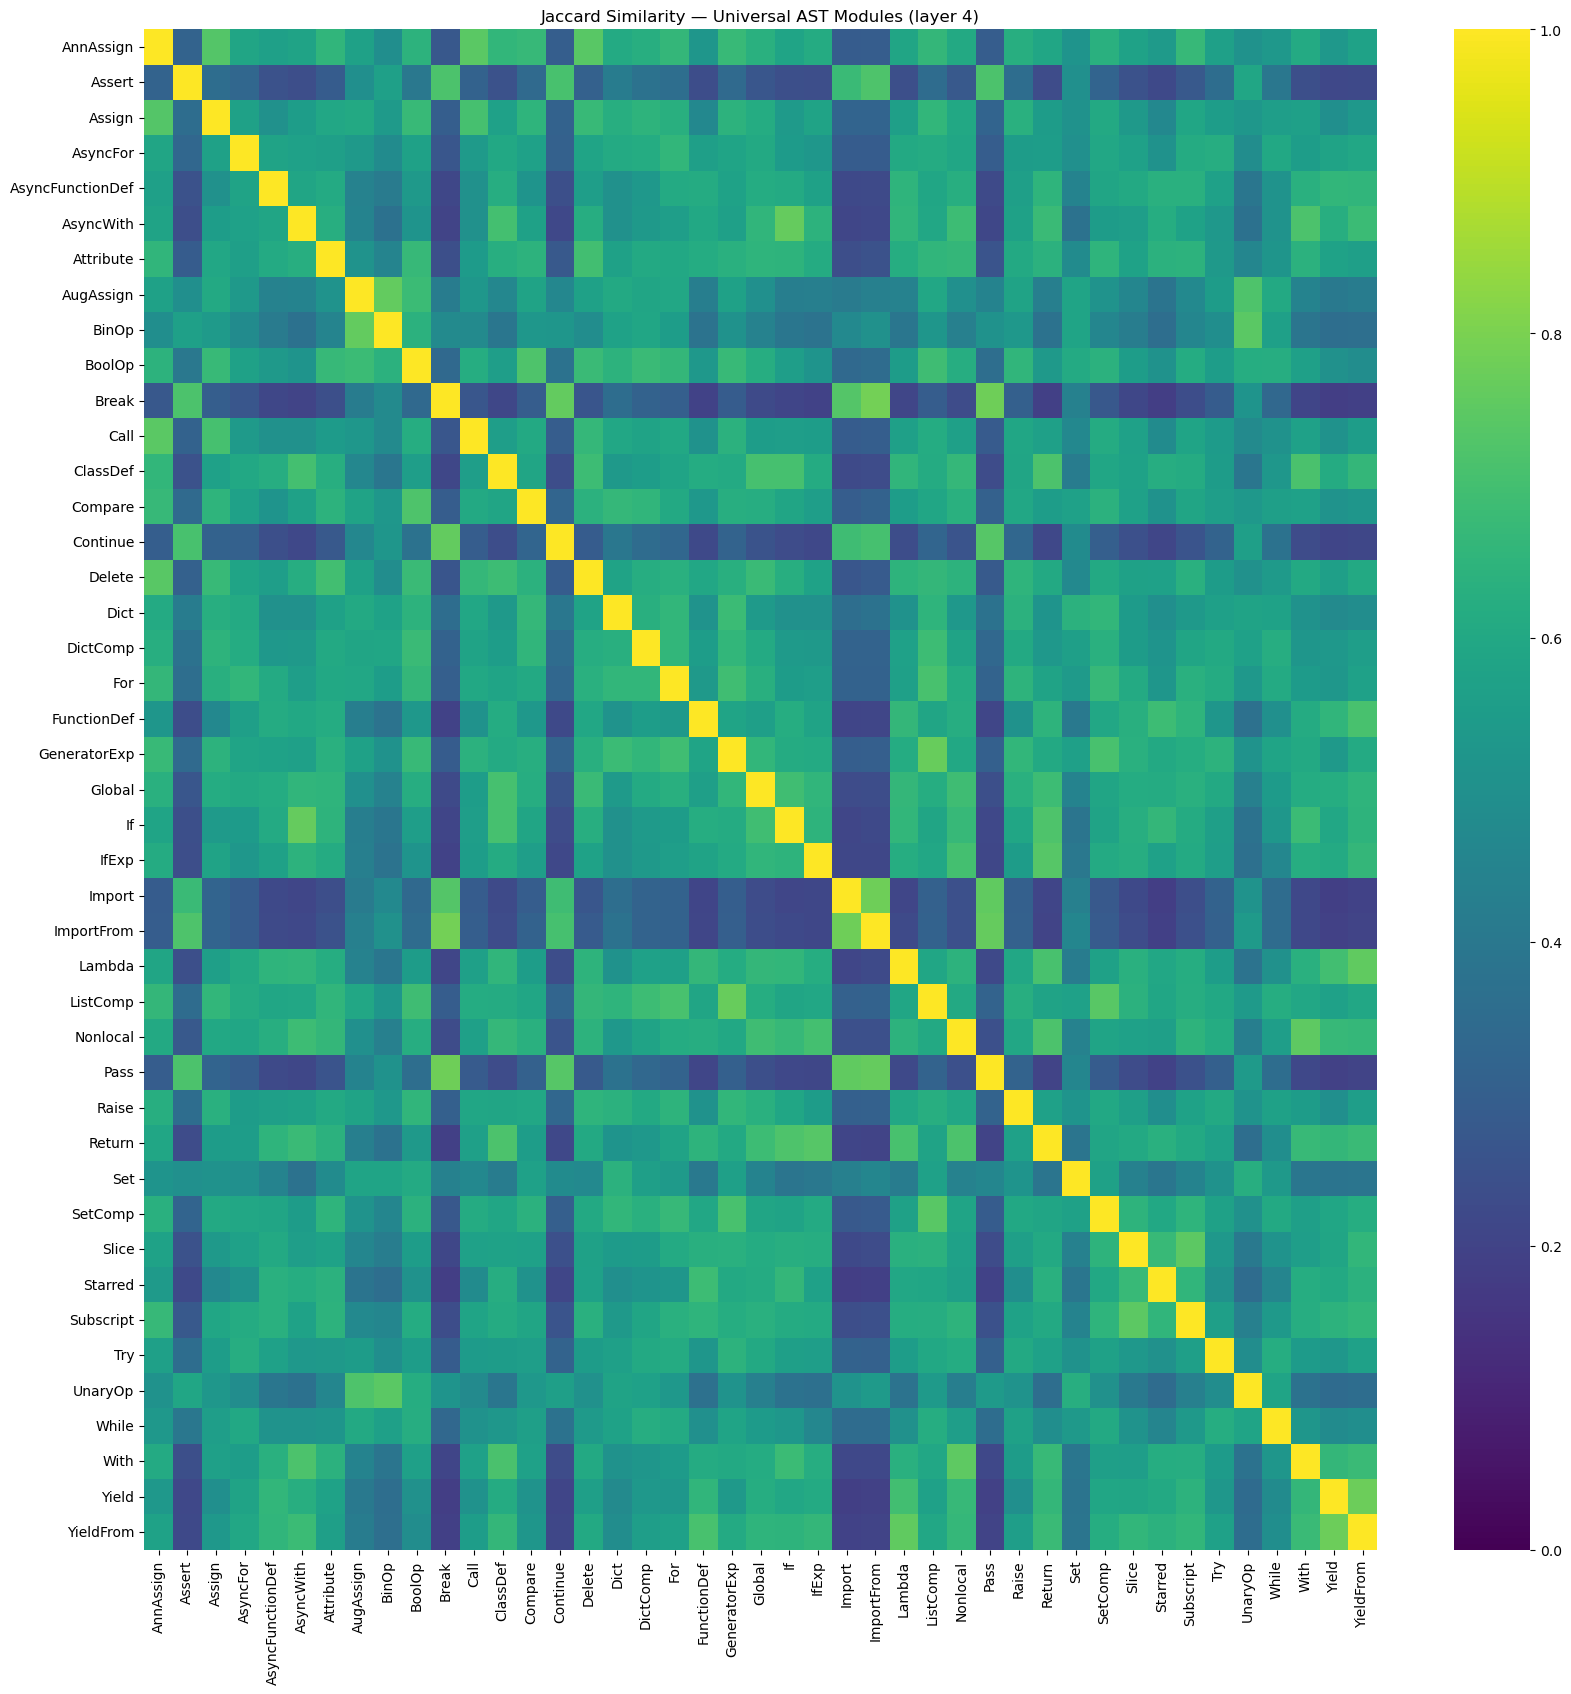

Jaccard Similarity — Universal AST Modules (layer 4)
  Mean Jaccard: 0.5091
  Max  Jaccard: 0.7861
  Pairs with J>0.5: 585


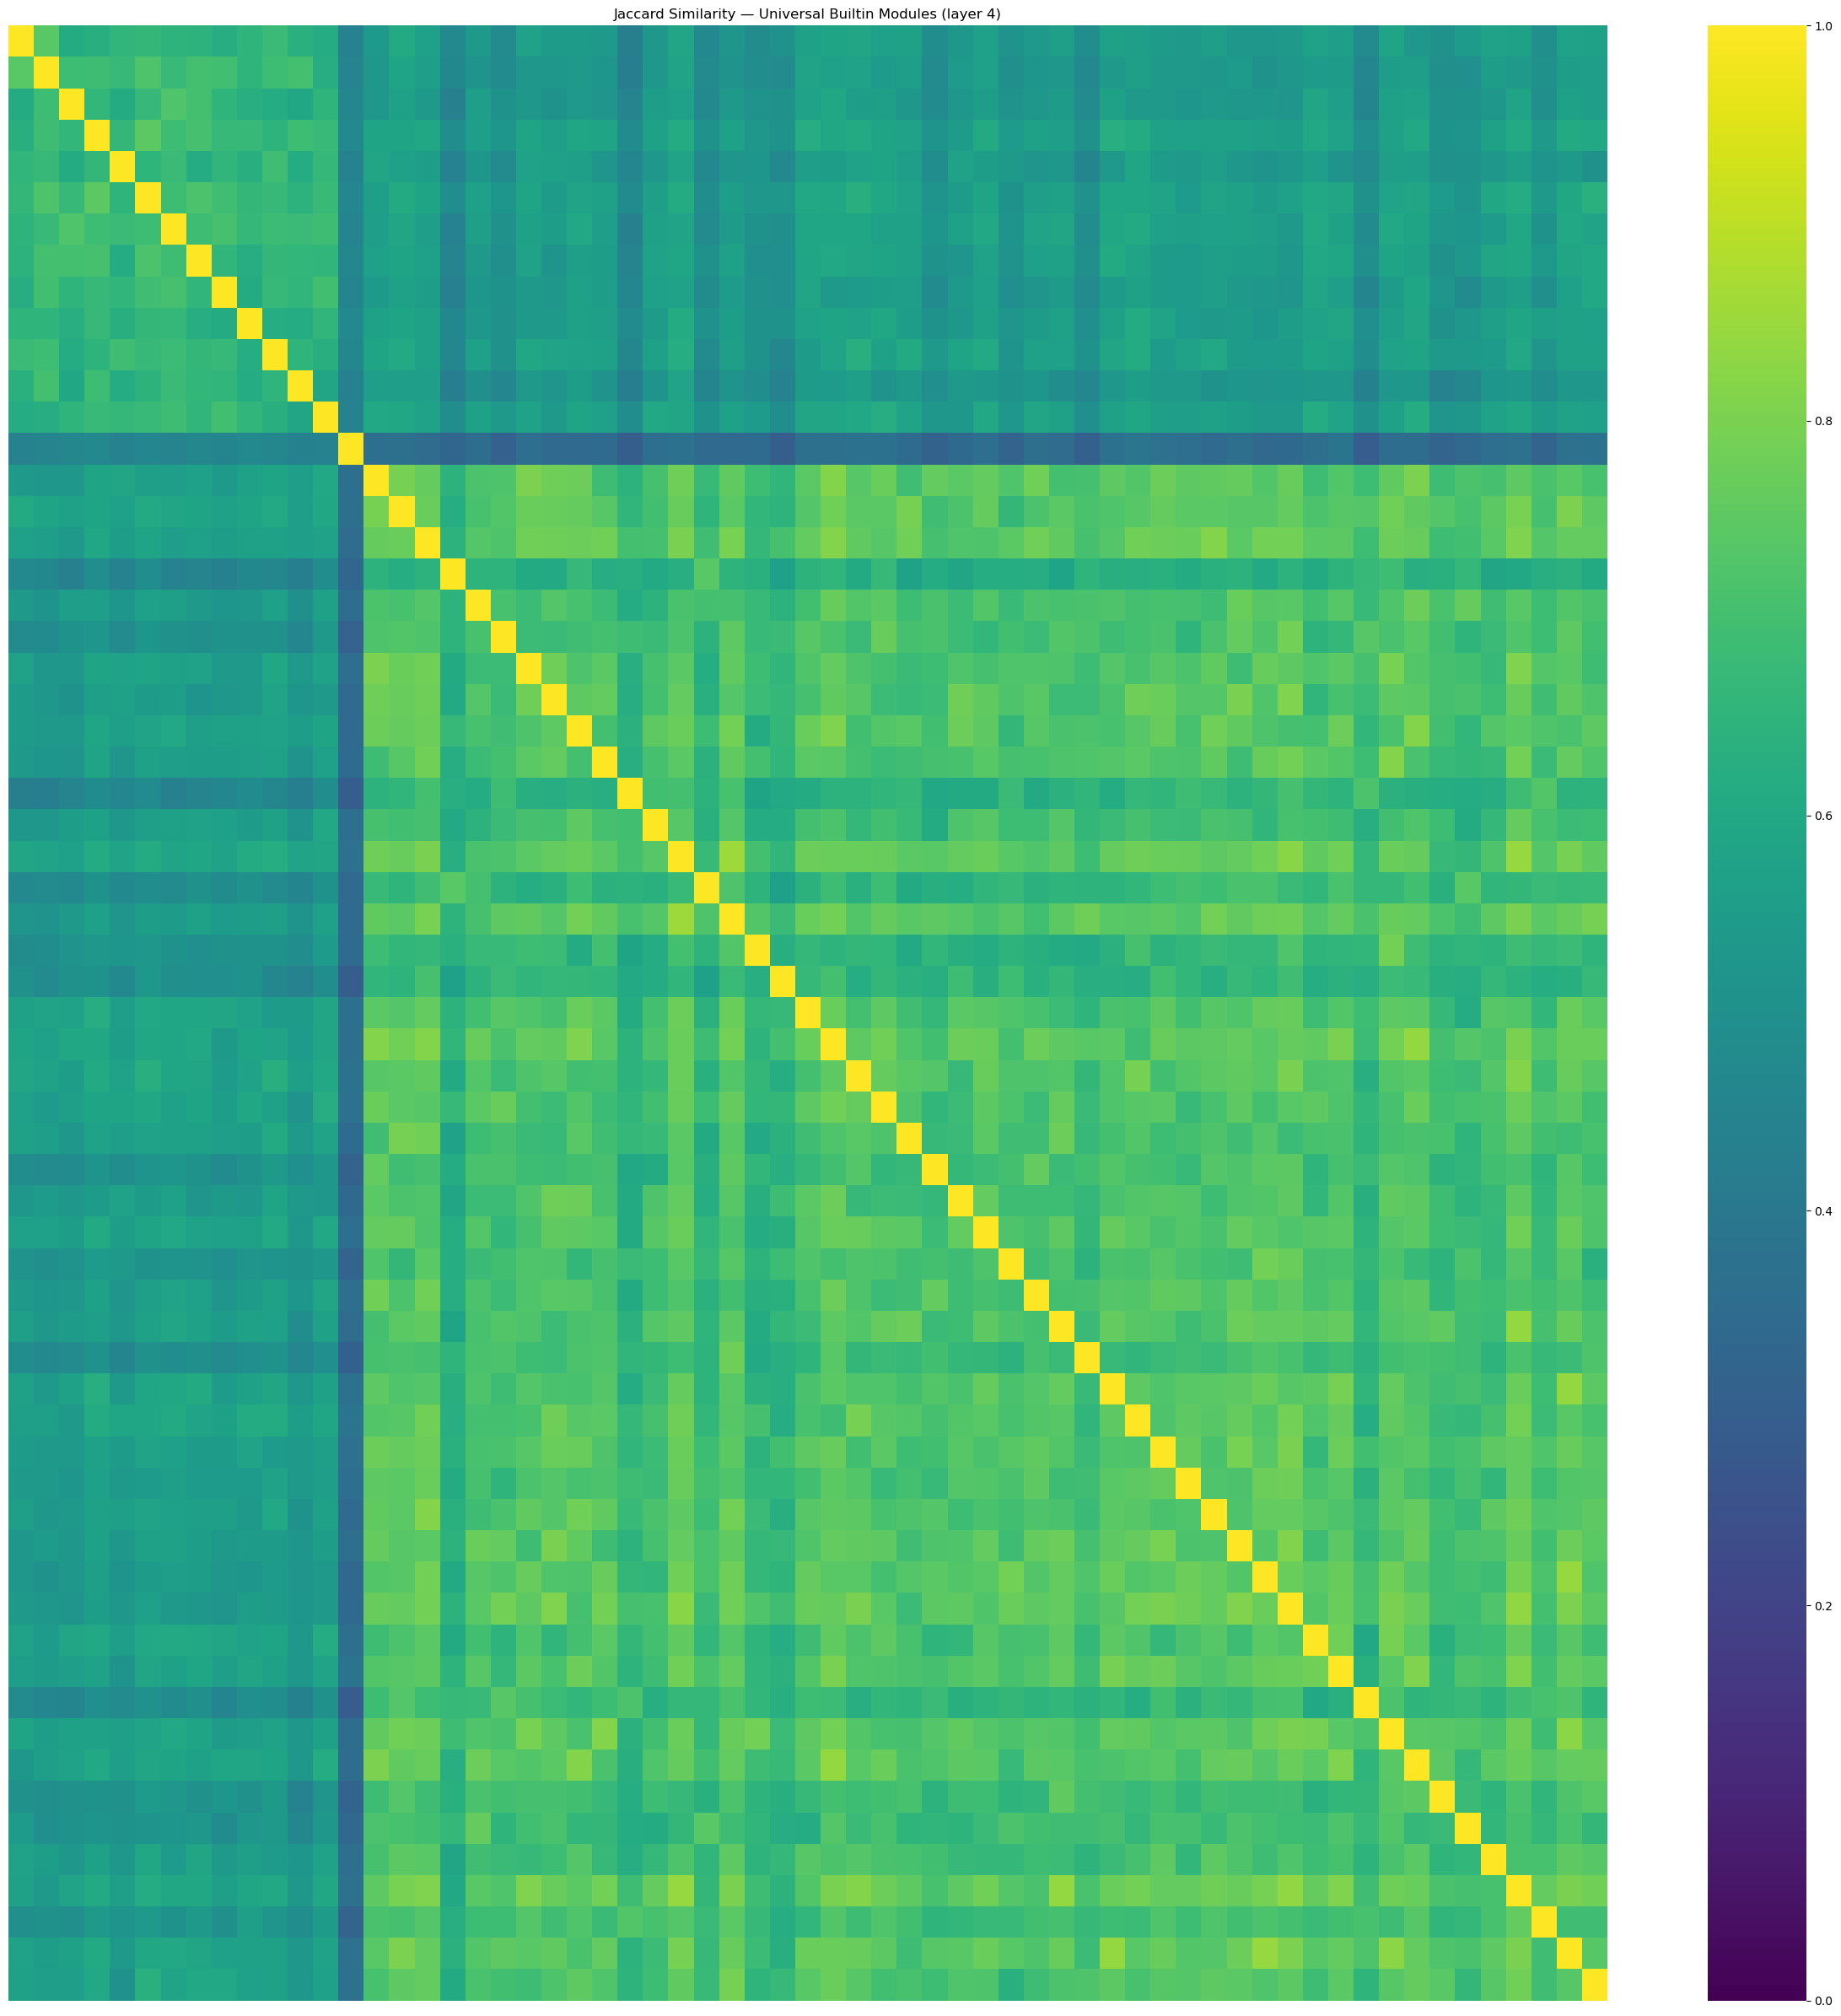

Jaccard Similarity — Universal Builtin Modules (layer 4)
  Mean Jaccard: 0.6440
  Max  Jaccard: 0.8523
  Pairs with J>0.5: 1794


In [ ]:
# Cell 4 – Protocol 2: Circuit Overlap (Jaccard heatmaps)
import matplotlib.pyplot as plt, seaborn as sns, numpy as np

def plot_jaccard_heatmap(mat, names, title, max_labels=50):
    fig, ax = plt.subplots(figsize=(min(24, len(names)*0.35+2),
                                    min(24, len(names)*0.35+2)))
    show = names if len(names) <= max_labels else False
    sns.heatmap(mat, ax=ax, vmin=0, vmax=1, cmap="viridis",
                xticklabels=show, yticklabels=show)
    ax.set_title(title)
    plt.tight_layout(); plt.show()
    off_diag = mat[np.triu_indices_from(mat, k=1)]
    print(f"{title}")
    print(f"  Mean Jaccard: {off_diag.mean():.4f}")
    print(f"  Max  Jaccard: {off_diag.max():.4f}")
    print(f"  Pairs with J>0.5: {(off_diag > 0.5).sum()}")

if "jaccard_ast_matrix" in metrics:
    names_m = metrics.get("ast_names", sorted(universal_masks["ast"]))
    plot_jaccard_heatmap(metrics["jaccard_ast_matrix"], names_m,
                         "Jaccard Similarity — Universal AST Modules (layer 4)")

if "jaccard_builtin_matrix" in metrics:
    names_m = metrics.get("builtin_names", sorted(universal_masks["builtin"]))
    plot_jaccard_heatmap(metrics["jaccard_builtin_matrix"], names_m,
                         "Jaccard Similarity — Universal Builtin Modules (layer 4)")


## Protocol 3: Layer Evolution

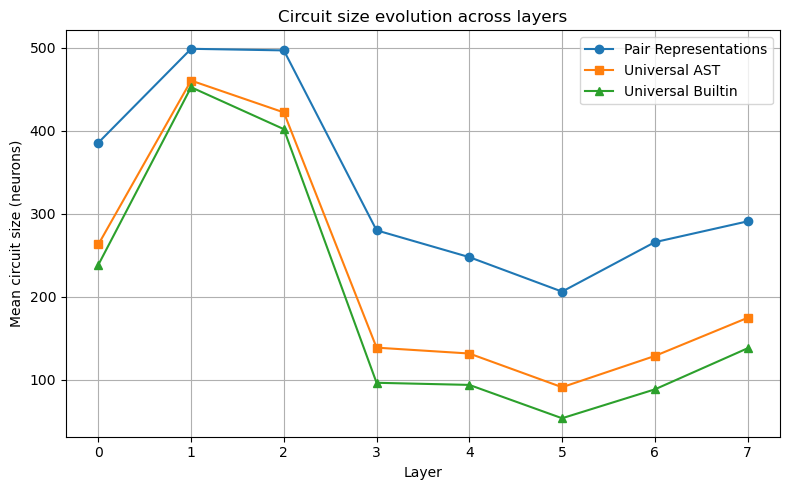

In [ ]:
# Cell 5 – Protocol 3: Layer Evolution
import numpy as np, matplotlib.pyplot as plt

layer_ids = sorted({lid for lm in pair_masks.values() for lid in lm})

def mean_size(masks_dict, lid):
    s = [lm[lid].sum() for lm in masks_dict.values() if lid in lm]
    return np.mean(s) if s else 0

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(layer_ids, [mean_size(pair_masks, l) for l in layer_ids],
        marker="o", label="Pair Representations")
ax.plot(layer_ids, [mean_size(universal_masks["ast"], l) for l in layer_ids],
        marker="s", label="Universal AST")
ax.plot(layer_ids, [mean_size(universal_masks["builtin"], l) for l in layer_ids],
        marker="^", label="Universal Builtin")
ax.set_xlabel("Layer"); ax.set_ylabel("Mean circuit size (neurons)")
ax.set_title("Circuit size evolution across layers")
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()


## Protocol 4: Compositionality (Entanglement Index)

E_I computed for 1276 pairs at layer 4
count    1276.000000
mean        0.568256
std         0.078858
min         0.000000
25%         0.553191
50%         0.590909
75%         0.612500
max         0.718663
Name: E_I, dtype: float64


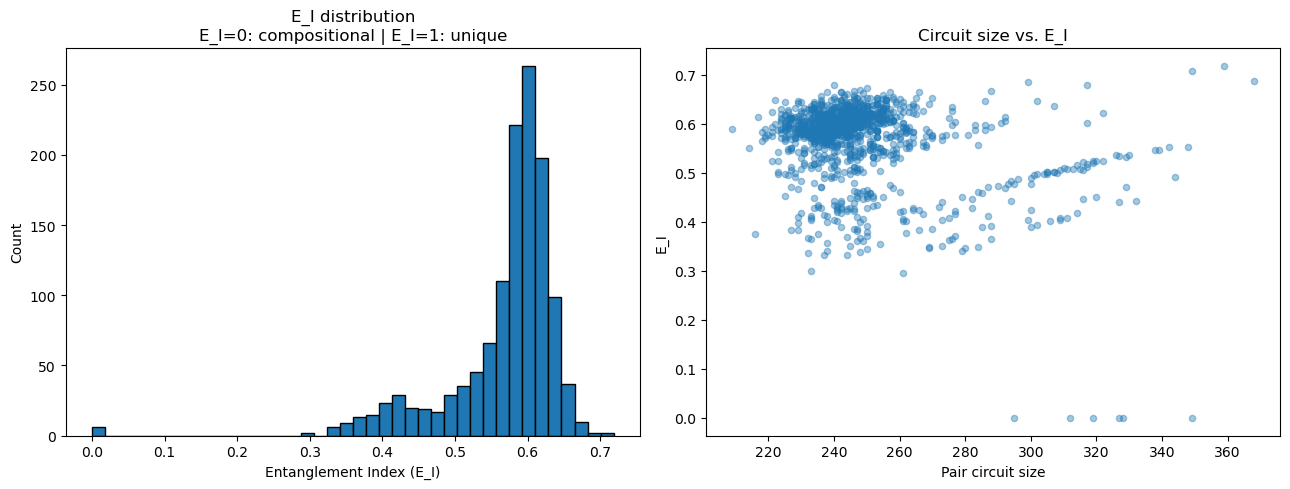

In [ ]:
# Cell 6 – Protocol 4: Compositionality (Entanglement Index)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from module2.metrics import entanglement_index

REP_LAYER = 4
ei_rows = []

for (ast_n, blt_o), lm in pair_masks.items():
    if REP_LAYER not in lm:
        continue
    pm = lm[REP_LAYER]
    am = universal_masks["ast"].get(ast_n, {}).get(REP_LAYER)
    bm = universal_masks["builtin"].get(blt_o, {}).get(REP_LAYER)
    if am is None or bm is None:
        continue
    ei_rows.append({
        "ast_node": ast_n, "builtin_obj": blt_o,
        "E_I": entanglement_index(pm, am, bm),
        "pair_size": int(pm.sum()),
    })

ei_df = pd.DataFrame(ei_rows)
print(f"E_I computed for {len(ei_df)} pairs at layer {REP_LAYER}")
print(ei_df["E_I"].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(ei_df["E_I"].values, bins=40, edgecolor="black")
axes[0].set_xlabel("Entanglement Index (E_I)")
axes[0].set_ylabel("Count")
axes[0].set_title("E_I distribution\nE_I=0: compositional | E_I=1: unique")

axes[1].scatter(ei_df["pair_size"], ei_df["E_I"], alpha=0.4, s=20)
axes[1].set_xlabel("Pair circuit size")
axes[1].set_ylabel("E_I")
axes[1].set_title("Circuit size vs. E_I")
plt.tight_layout(); plt.show()


In [ ]:
# Cell 7 – Protocol 4 continued: most/least compositional pairs
print("Most compositional pairs (lowest E_I):")
print(ei_df.nsmallest(10, "E_I")[["ast_node","builtin_obj","E_I"]].to_string(index=False))
print("\nLeast compositional pairs (highest E_I):")
print(ei_df.nlargest(10, "E_I")[["ast_node","builtin_obj","E_I"]].to_string(index=False))


Most compositional pairs (lowest E_I):
  ast_node       builtin_obj      E_I
    Assert        _isolated_ 0.000000
     Break        _isolated_ 0.000000
  Continue        _isolated_ 0.000000
ImportFrom        _isolated_ 0.000000
    Import        _isolated_ 0.000000
      Pass        _isolated_ 0.000000
   UnaryOp           complex 0.295019
       Set             float 0.300429
       Set              bool 0.331967
     Raise FileNotFoundError 0.333333

Least compositional pairs (highest E_I):
 ast_node builtin_obj      E_I
AnnAssign       float 0.718663
AnnAssign        bool 0.707736
  Compare        bool 0.687500
Subscript   bytearray 0.685619
    Yield         set 0.679167
   Delete       float 0.678233
    Yield       float 0.672000
  Starred       bytes 0.669355
Subscript       range 0.666667
YieldFrom  memoryview 0.666667


## Protocol 5: Marginalization Robustness

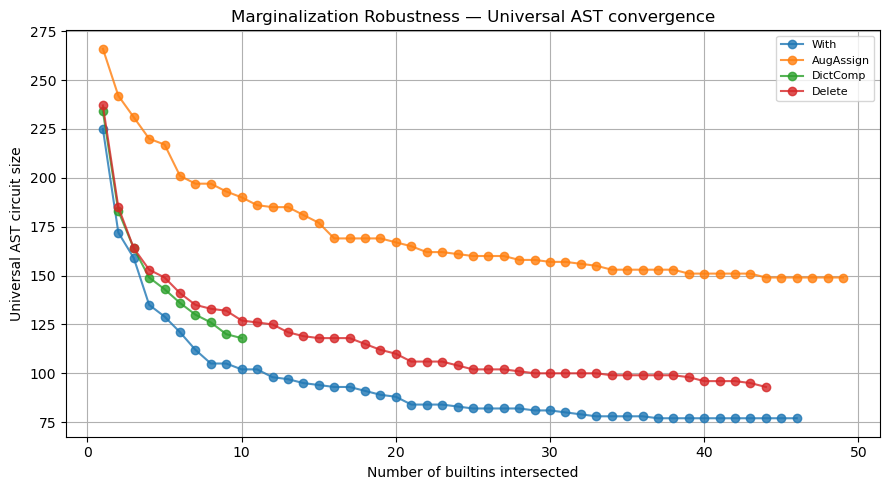

In [ ]:
# Cell 8 – Protocol 5: Marginalization Robustness — AST
import numpy as np, matplotlib.pyplot as plt, random

random.seed(42)
sample_ast = random.sample(sorted(universal_masks["ast"]), min(5, len(universal_masks["ast"])))

fig, ax = plt.subplots(figsize=(9, 5))
for ast_n in sample_ast:
    blts = [b for (a, b) in pair_masks if a == ast_n and REP_LAYER in pair_masks[(a, b)]]
    if len(blts) < 2:
        continue
    random.shuffle(blts)
    running, sizes = None, []
    for blt in blts:
        pm = pair_masks[(ast_n, blt)][REP_LAYER]
        running = pm.copy() if running is None else np.logical_and(running, pm)
        sizes.append(int(running.sum()))
    ax.plot(range(1, len(sizes)+1), sizes, marker="o", label=ast_n, alpha=0.8)

ax.set_xlabel("Number of builtins intersected")
ax.set_ylabel("Universal AST circuit size")
ax.set_title("Marginalization Robustness — Universal AST convergence")
ax.legend(fontsize=8); ax.grid(True)
plt.tight_layout(); plt.show()


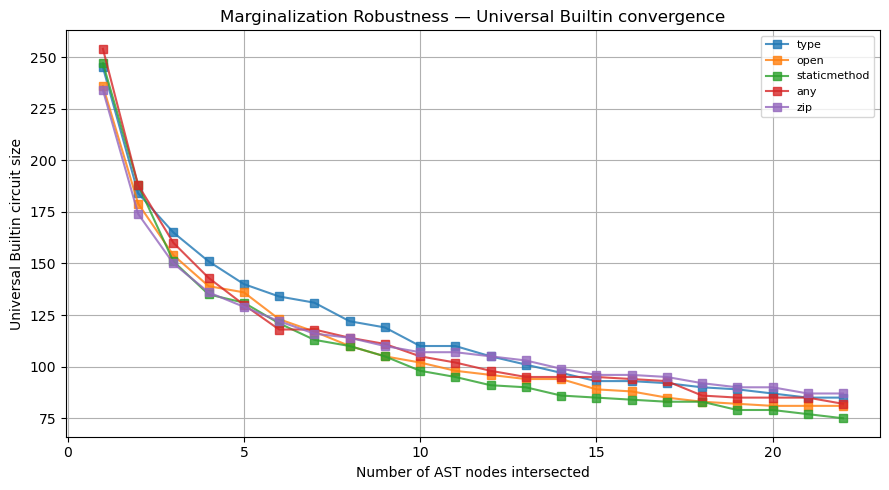

In [ ]:
# Cell 9 – Protocol 5 continued: Builtin marginalization robustness
import numpy as np, matplotlib.pyplot as plt, random

sample_blt = random.sample(sorted(universal_masks["builtin"]), min(5, len(universal_masks["builtin"])))

fig, ax = plt.subplots(figsize=(9, 5))
for blt_o in sample_blt:
    asts = [a for (a, b) in pair_masks if b == blt_o and REP_LAYER in pair_masks[(a, b)]]
    if len(asts) < 2:
        continue
    random.shuffle(asts)
    running, sizes = None, []
    for ast_n in asts:
        pm = pair_masks[(ast_n, blt_o)][REP_LAYER]
        running = pm.copy() if running is None else np.logical_and(running, pm)
        sizes.append(int(running.sum()))
    ax.plot(range(1, len(sizes)+1), sizes, marker="s", label=blt_o, alpha=0.8)

ax.set_xlabel("Number of AST nodes intersected")
ax.set_ylabel("Universal Builtin circuit size")
ax.set_title("Marginalization Robustness — Universal Builtin convergence")
ax.legend(fontsize=8); ax.grid(True)
plt.tight_layout(); plt.show()


## Ockham Index (O_I)

In [ ]:
# Cell 10 – Ockham Index (Jaccard distance between Universal Modules)
from module2.metrics import jaccard_distance
import pandas as pd

ast_sorted = sorted(universal_masks["ast"])
oi_rows = []
for i, a1 in enumerate(ast_sorted):
    m1 = universal_masks["ast"][a1].get(REP_LAYER)
    if m1 is None: continue
    for a2 in ast_sorted[i+1:]:
        m2 = universal_masks["ast"][a2].get(REP_LAYER)
        if m2 is None: continue
        oi_rows.append({"a": a1, "b": a2, "O_I": jaccard_distance(m1, m2)})

oi_df = pd.DataFrame(oi_rows)
print("Ockham Index (AST x AST) — summary:")
print(oi_df["O_I"].describe())
print("\nMost similar AST node pairs (low O_I = high overlap):")
print(oi_df.nsmallest(10, "O_I")[["a","b","O_I"]].to_string(index=False))


Ockham Index (AST x AST) — summary:
count    903.000000
mean       0.490856
std        0.149461
min        0.213904
25%        0.383883
50%        0.442478
75%        0.604456
max        0.818182
Name: O_I, dtype: float64

Most similar AST node pairs (low O_I = high overlap):
           a          b      O_I
       Break ImportFrom 0.213904
       Break       Pass 0.221053
      Import ImportFrom 0.222527
       Yield  YieldFrom 0.223684
GeneratorExp   ListComp 0.231405
  ImportFrom       Pass 0.234973
   AsyncWith         If 0.235294
   AugAssign      BinOp 0.240437
       Break   Continue 0.242021
      Lambda  YieldFrom 0.243902


## Summary Report

In [ ]:
# Cell 11 – Summary report (saved to file)
import json, datetime

report = {
    "generated_at"        : datetime.datetime.utcnow().isoformat() + "Z",
    "input_file"          : UNIVERSAL_FILE,
    "n_pairs"             : len(pair_masks),
    "n_universal_ast"     : len(universal_masks["ast"]),
    "n_universal_builtin" : len(universal_masks["builtin"]),
    "mean_EI"             : float(ei_df["E_I"].mean()) if len(ei_df) else None,
    "median_EI"           : float(ei_df["E_I"].median()) if len(ei_df) else None,
    "fraction_EI_lt_0.2"  : float((ei_df["E_I"] < 0.2).mean()) if len(ei_df) else None,
    "mean_OI_ast"         : float(oi_df["O_I"].mean()) if len(oi_df) else None,
    "metadata"            : {str(k): str(v) for k, v in metadata.items()},
}

# Layer evolution data
layer_ids = sorted({lid for lm in pair_masks.values() for lid in lm})
def mean_size(masks_dict, lid):
    s = [lm[lid].sum() for lm in masks_dict.values() if lid in lm]
    return float(np.mean(s)) if s else 0.0

report["layer_evolution"] = {
    "layers": layer_ids,
    "pair_sizes": [mean_size(pair_masks, l) for l in layer_ids],
    "ast_sizes": [mean_size(universal_masks["ast"], l) for l in layer_ids],
    "builtin_sizes": [mean_size(universal_masks["builtin"], l) for l in layer_ids],
}

# Save JSON
date_str = datetime.date.today().isoformat()
json_path = os.path.join(DATA_DIR, f"report_3A_evaluation_{date_str}.json")
with open(json_path, "w") as f:
    json.dump(report, f, indent=2, default=str)

# Save TXT
txt_path = os.path.join(DATA_DIR, f"report_3A_evaluation_{date_str}.txt")
with open(txt_path, "w") as f:
    f.write("EVALUATION REPORT — 3A\n")
    f.write(f"Generated: {report['generated_at']}\n")
    f.write(f"Input: {UNIVERSAL_FILE}\n")
    f.write(f"\n{'='*70}\n\n")
    
    f.write("UNIVERSAL OBJECTS\n")
    f.write(f"  Pairs              : {report['n_pairs']}\n")
    f.write(f"  Universal AST      : {report['n_universal_ast']}\n")
    f.write(f"  Universal Builtin  : {report['n_universal_builtin']}\n")
    
    f.write(f"\n{'='*70}\n\n")
    f.write("ENTANGLEMENT INDEX (Compositionality)\n")
    f.write(f"  Mean E_I           : {report['mean_EI']:.4f}\n")
    f.write(f"  Median E_I         : {report['median_EI']:.4f}\n")
    f.write(f"  Fraction E_I < 0.2 : {report['fraction_EI_lt_0.2']:.4f}\n")
    
    f.write(f"\n  Most compositional pairs (lowest E_I):\n")
    for _, row in ei_df.nsmallest(10, "E_I").iterrows():
        f.write(f"    E_I={row['E_I']:.4f} | {row['ast_node']:>20s} × {row['builtin_obj']}\n")
    
    f.write(f"\n  Least compositional pairs (highest E_I):\n")
    for _, row in ei_df.nlargest(10, "E_I").iterrows():
        f.write(f"    E_I={row['E_I']:.4f} | {row['ast_node']:>20s} × {row['builtin_obj']}\n")
    
    f.write(f"\n{'='*70}\n\n")
    f.write("OCKHAM INDEX (AST × AST similarity)\n")
    f.write(f"  Mean O_I           : {report['mean_OI_ast']:.4f}\n")
    
    f.write(f"\n  Most similar AST pairs (lowest O_I):\n")
    for _, row in oi_df.nsmallest(10, "O_I").iterrows():
        f.write(f"    O_I={row['O_I']:.4f} | {row['a']:>20s} × {row['b']}\n")
    
    f.write(f"\n{'='*70}\n\n")
    f.write("LAYER EVOLUTION (mean circuit size per layer)\n")
    f.write(f"  {'Layer':>5s}  {'Pairs':>8s}  {'AST':>8s}  {'Builtin':>8s}\n")
    le = report["layer_evolution"]
    for i, lid in enumerate(le["layers"]):
        f.write(f"  {lid:>5d}  {le['pair_sizes'][i]:>8.1f}  {le['ast_sizes'][i]:>8.1f}  {le['builtin_sizes'][i]:>8.1f}\n")

print(f"Reports saved:")
print(f"  JSON: {json_path}")
print(f"  TXT:  {txt_path}")
print(json.dumps(report, indent=2, default=str))

# Close atlas HDF5 handle
handle = atlas.get("handle")
if handle and handle.id.valid:
    handle.close()
    print("HDF5 handle closed.")

Reports saved:
  JSON: /Users/piotrwilam/Data/CSP-Atlas/report_3A_evaluation_2026-03-18.json
  TXT:  /Users/piotrwilam/Data/CSP-Atlas/report_3A_evaluation_2026-03-18.txt
{
  "generated_at": "2026-03-18T17:12:54.398495Z",
  "input_file": "universal_106x50.h5",
  "n_pairs": 1276,
  "n_universal_ast": 43,
  "n_universal_builtin": 63,
  "mean_EI": 0.5682559325936819,
  "median_EI": 0.5909090909090909,
  "fraction_EI_lt_0.2": 0.004702194357366771,
  "mean_OI_ast": 0.4908558261961735,
  "metadata": {
    "consistency_thresh": "0.8",
    "epsilon": "0.001",
    "model_id": "openai/circuit-sparsity",
    "n_layers": "8",
    "n_pairs": "1276",
    "ast_nodes": "['AnnAssign', 'Assert', 'Assign', 'AsyncFor', 'AsyncFunctionDef', 'AsyncWith', 'Attribute', 'AugAssign', 'BinOp', 'BoolOp', 'Break', 'Call', 'ClassDef', 'Compare', 'Continue', 'Delete', 'Dict', 'DictComp', 'For', 'FunctionDef', 'GeneratorExp', 'Global', 'If', 'IfExp', 'Import', 'ImportFrom', 'Lambda', 'ListComp', 'Nonlocal', 'Pass', 'Ra

/var/folders/jg/43wv0zmx2bj32_n9g_26mhjc0000gn/T/ipykernel_64066/2759611046.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generated_at"        : datetime.datetime.utcnow().isoformat() + "Z",


In [ ]:
# Cell 12 – Done
print("Module 2 evaluation complete.")
print("All 5 protocols executed:")
print("  1. Topology Map (UMAP)")
print("  2. Circuit Overlap (Jaccard heatmaps)")
print("  3. Layer Evolution")
print("  4. Compositionality (Entanglement Index)")
print("  5. Marginalization Robustness")


Module 2 evaluation complete.
All 5 protocols executed:
  1. Topology Map (UMAP)
  2. Circuit Overlap (Jaccard heatmaps)
  3. Layer Evolution
  4. Compositionality (Entanglement Index)
  5. Marginalization Robustness
